In [3]:
print("Hello World")

Hello World


# CODE ARCHITECTURE
Imports <br>
Load one joint CSV <br>
Timestamp conversion <br> 
Acceleration calculation <br>
Friction torque calculation <br>
Data visualization <br>
Prepare features <br>
Scaling <br>
Train/Test split <br>
PINN parameters <br>
Neural Network <br>
Training loop <br>
Parameter estimation <br>
Prediction <br>
Friction curve <br>

# IMPORT PACKAGES AND LIBRARIES

In [4]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


# IMPORT DATA FROM CSV FILES

In [5]:
folder_path = "S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data"

j1 = pd.read_csv(folder_path + r"\J_1_05.06.2026_14_46_55.csv")
j2 = pd.read_csv(folder_path + r"\J_2_05.06.2026_16_48_47.csv")
j3 = pd.read_csv(folder_path + r"\J_3_05.06.2026_14_43_16.csv")
j4 = pd.read_csv(folder_path + r"\J_4_05.06.2026_14_39_00.csv")
j5 = pd.read_csv(folder_path + r"\J_5_05.06.2026_14_29_39.csv")

print(j1.shape)
print(j2.shape)
print(j3.shape)
print(j4.shape)
print(j5.shape)

(49646, 25)
(24216, 25)
(12466, 25)
(42015, 25)
(34440, 25)


# PLOTTING THE TIMESTAMP VS MT JTS V Q

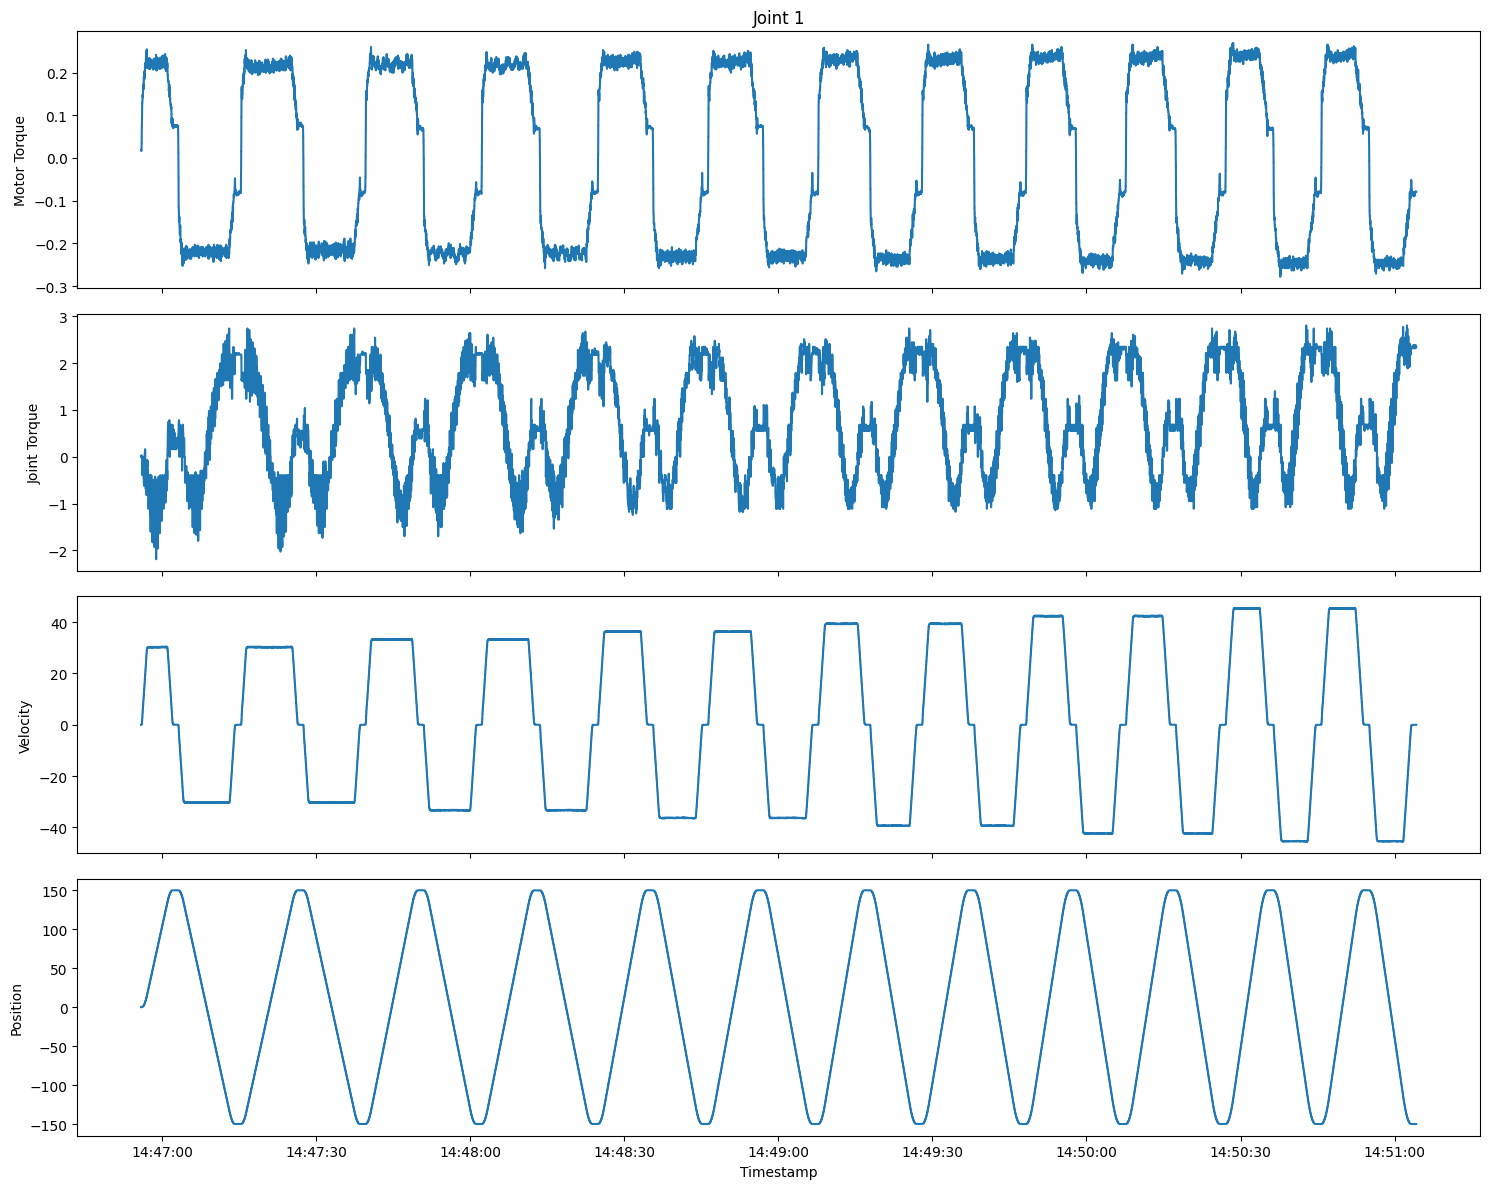

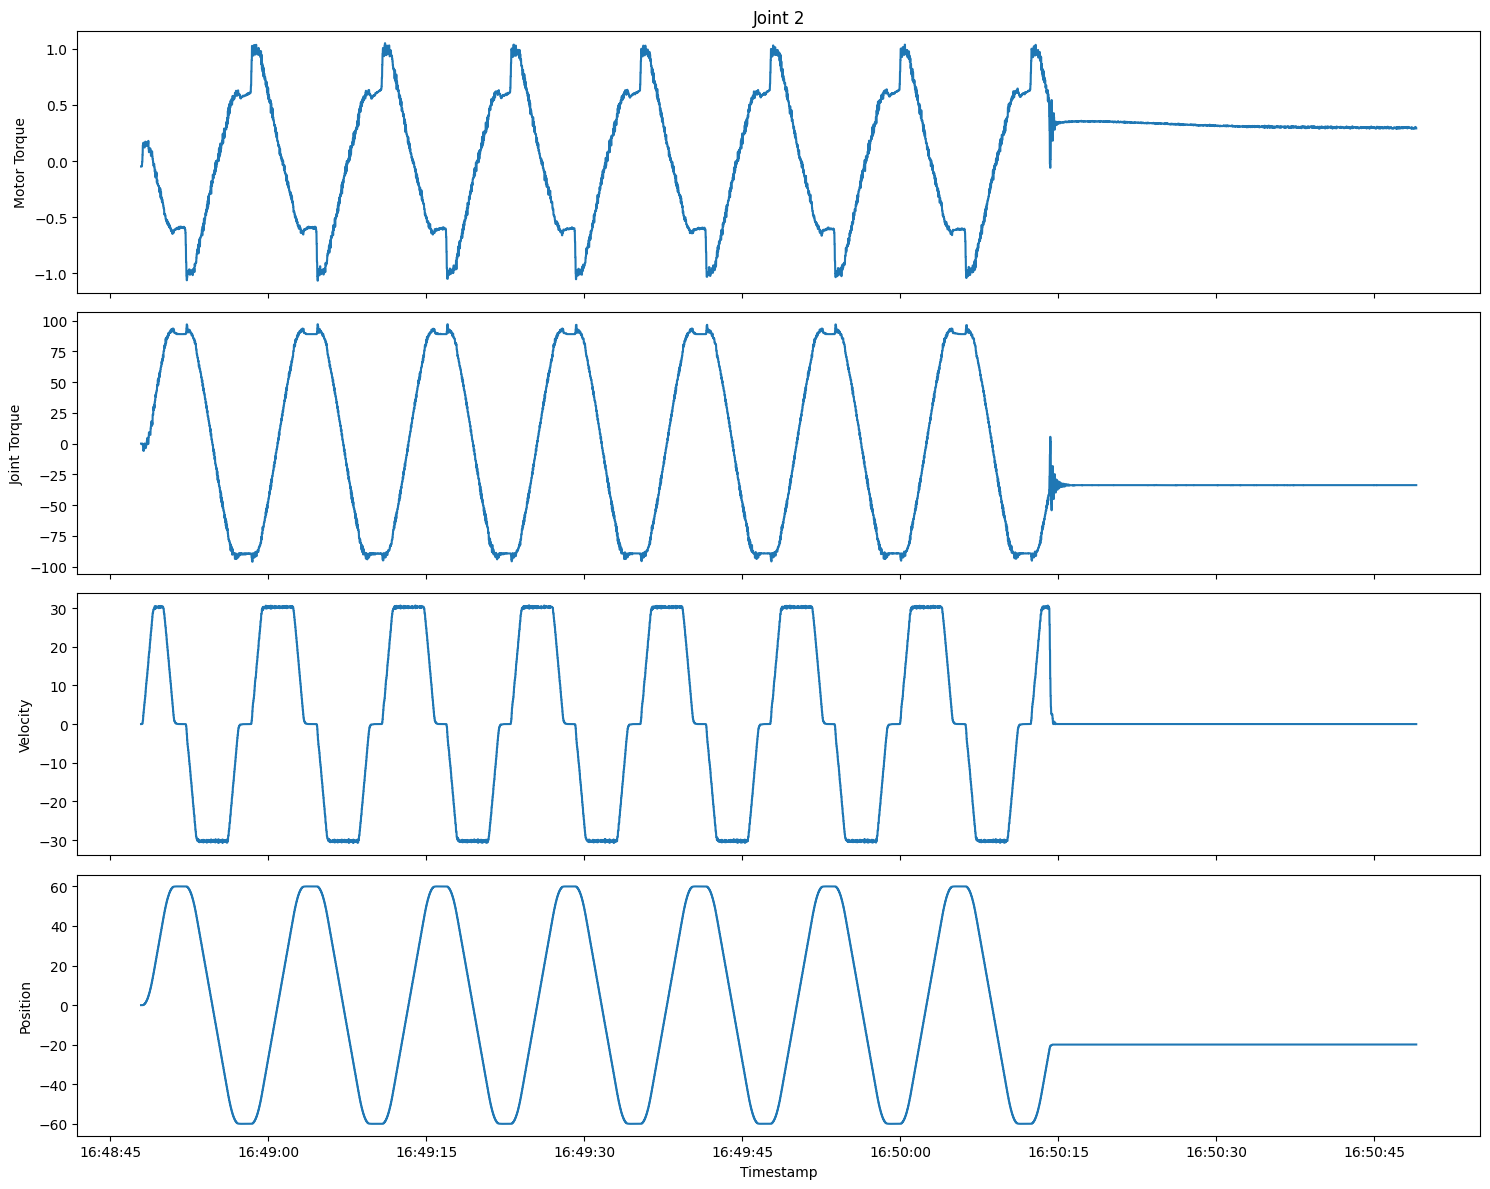

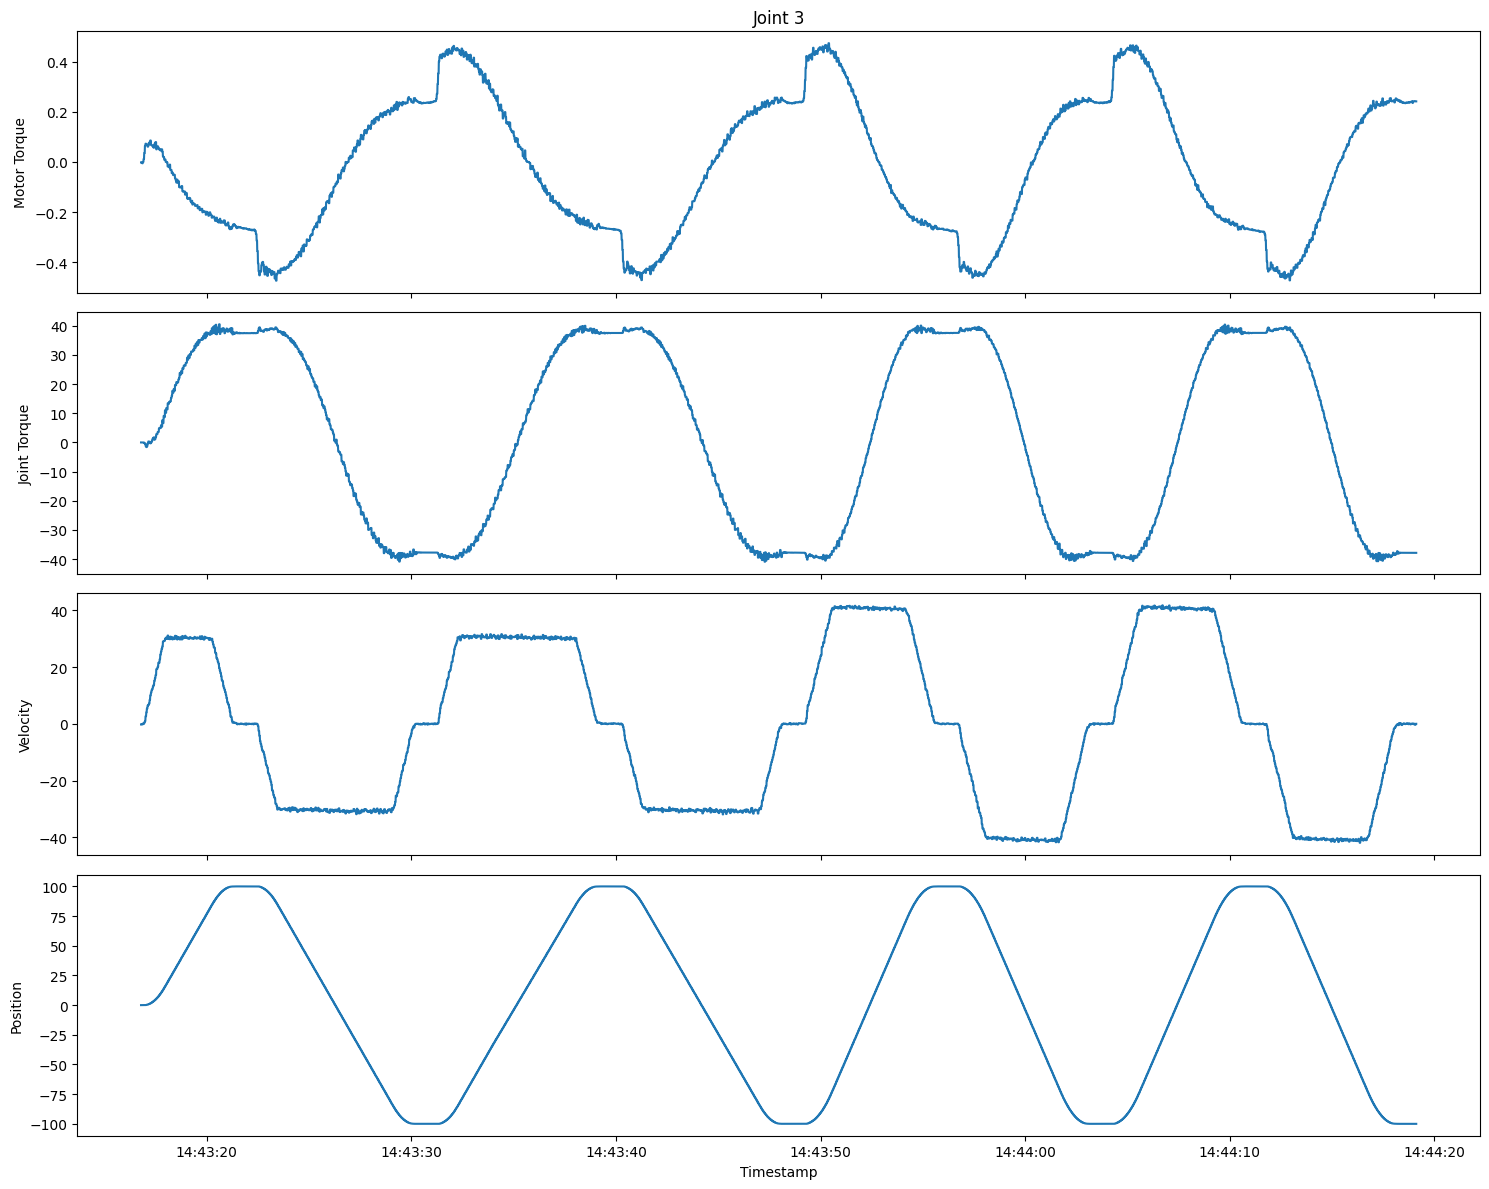

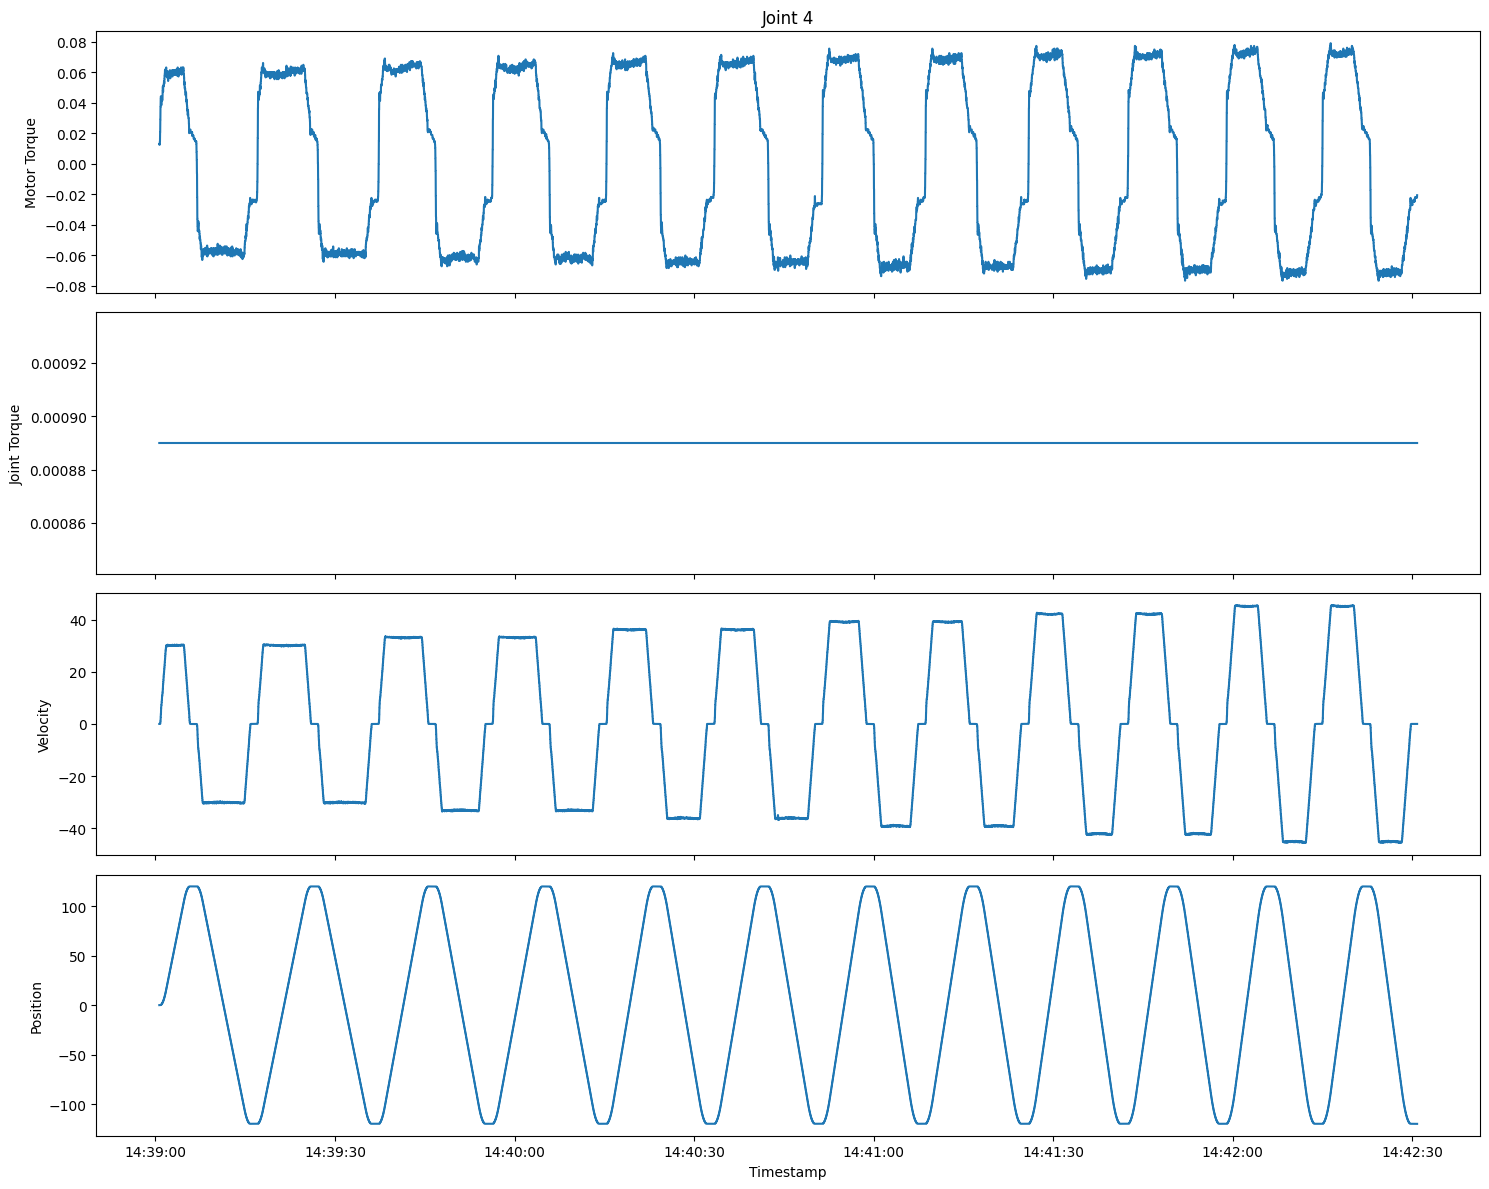

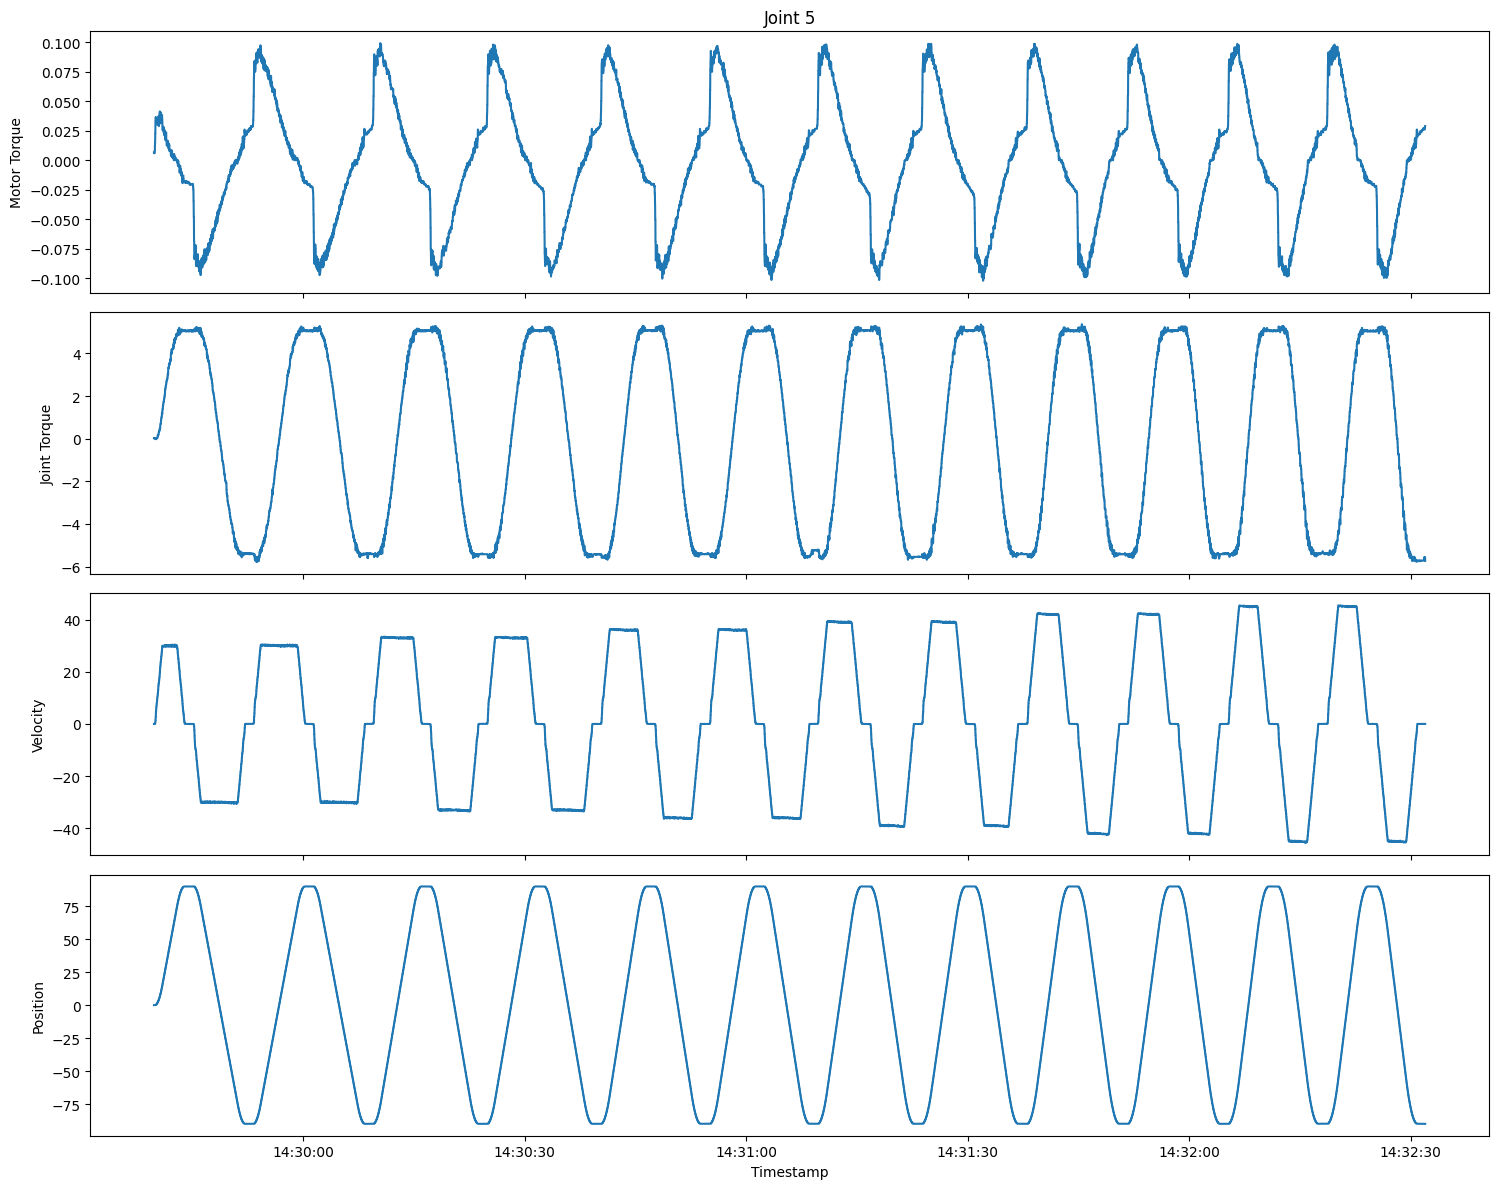

In [6]:
for df in [j1, j2, j3, j4, j5]:
    df["timestamp"] = pd.to_datetime(
        "2026-06-05 " + df["timestamp"].astype(str)
    )

joint_files = [j1, j2, j3, j4, j5]
for joint_no, df in zip([1,2,3,4,5], joint_files):
    fig, axs = plt.subplots(
        4, 1,
        figsize=(15,12),
        sharex=True
    )

    axs[0].plot(
        df["timestamp"],
        df[f"m_t_{joint_no}"]
    )
    axs[0].set_ylabel("Motor Torque")
    axs[0].set_title(f"Joint {joint_no}")

    axs[1].plot(
        df["timestamp"],
        df[f"jts{joint_no}"]
    )
    axs[1].set_ylabel("Joint Torque")

    axs[2].plot(
        df["timestamp"],
        df[f"v{joint_no}"]
    )
    axs[2].set_ylabel("Velocity")

    axs[3].plot(
        df["timestamp"],
        df[f"q{joint_no}"]
    )
    axs[3].set_ylabel("Position")
    axs[3].set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()

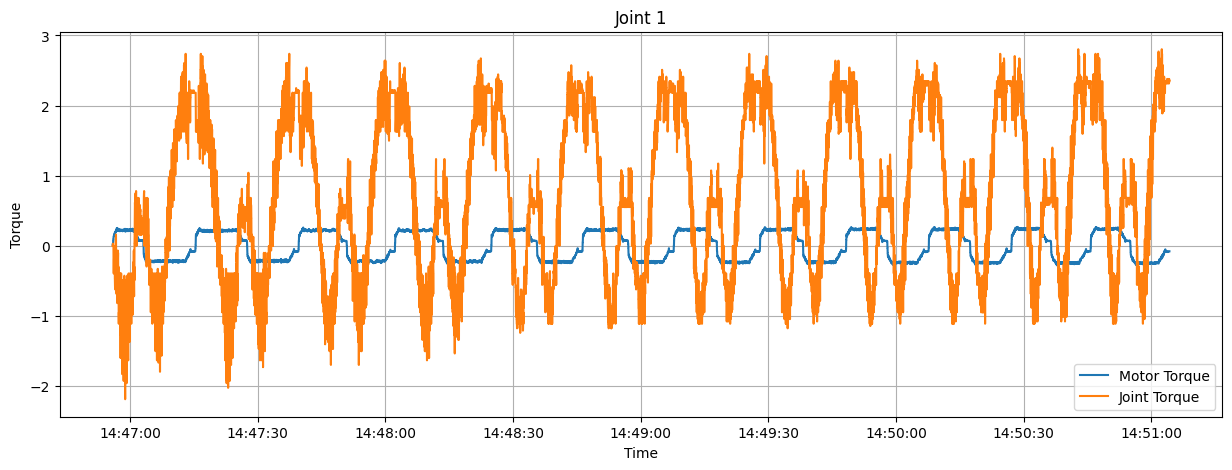

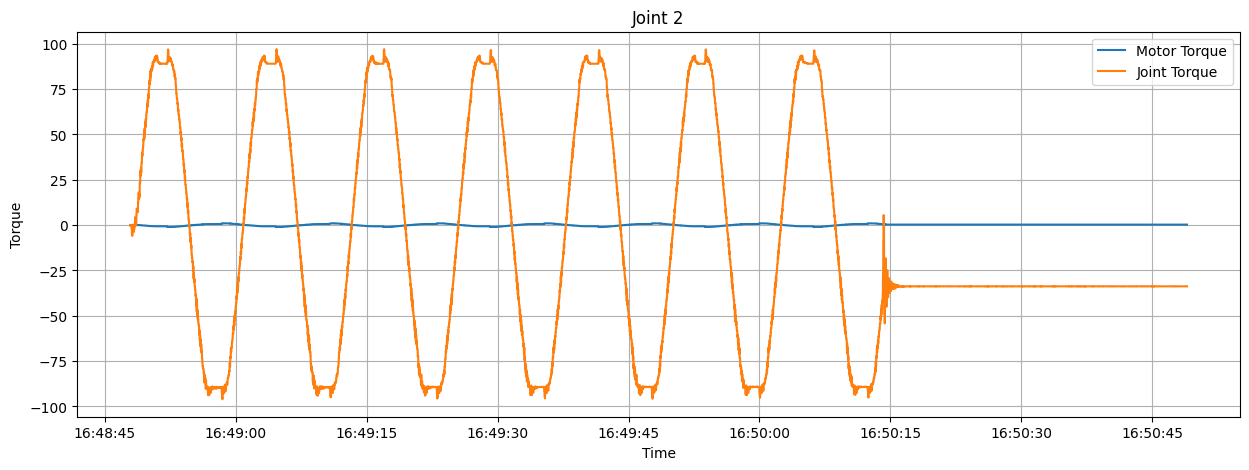

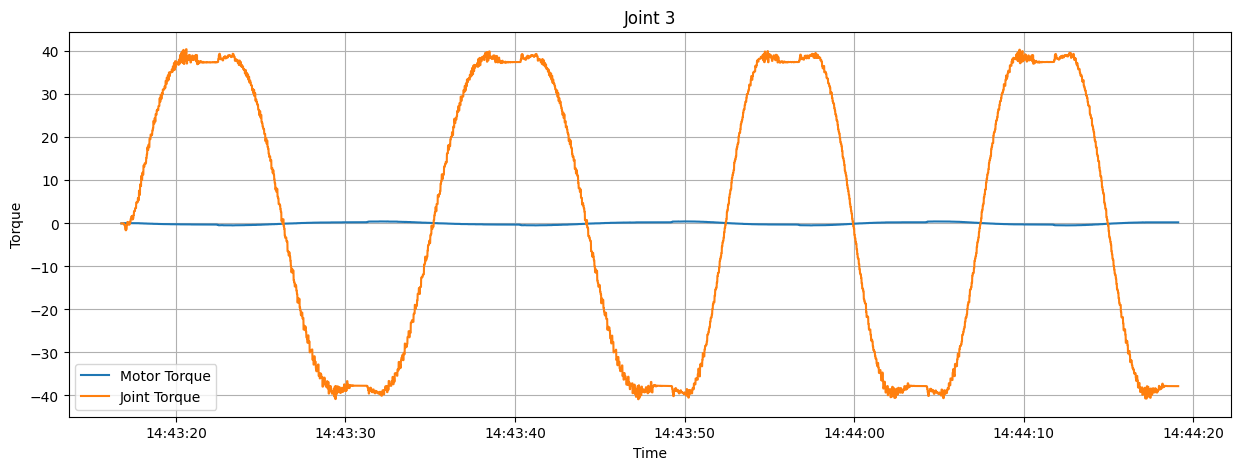

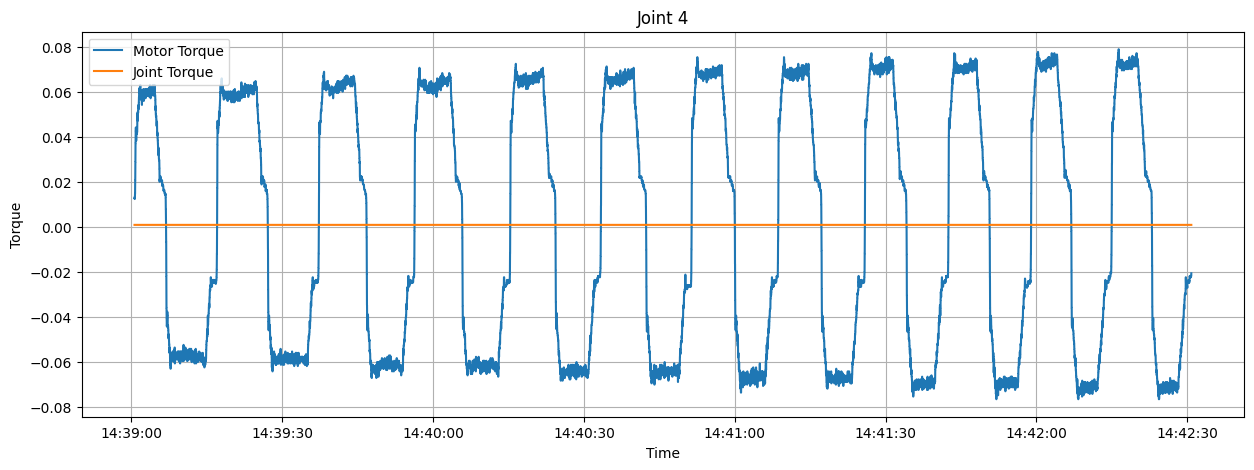

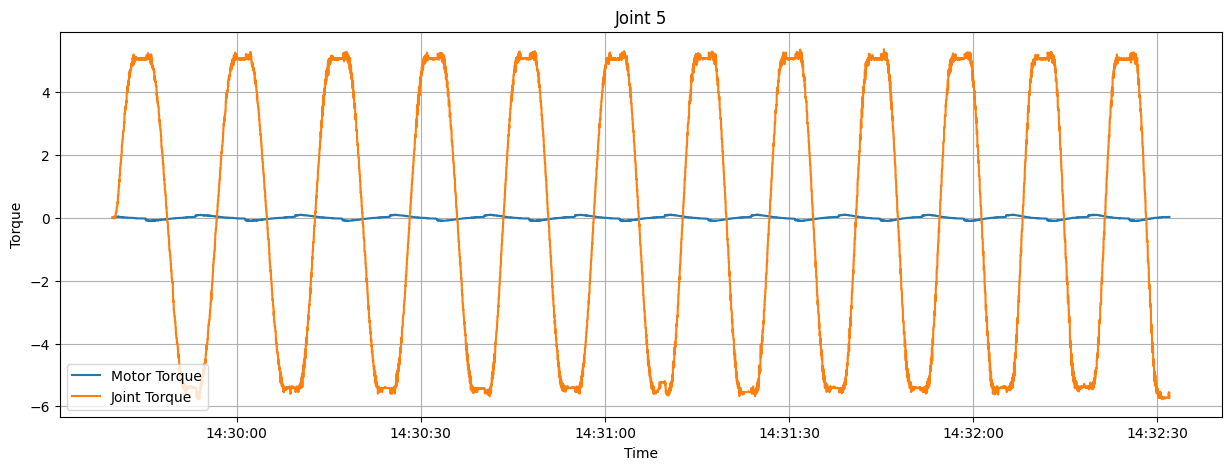

In [7]:
for joint_no, df in zip([1,2,3,4,5],[j1,j2,j3,j4,j5]):
    plt.figure(figsize=(15,5))

    plt.plot(
        df["timestamp"],
        df[f"m_t_{joint_no}"],
        label="Motor Torque"
    )

    plt.plot(
        df["timestamp"],
        df[f"jts{joint_no}"],
        label="Joint Torque"
    )

    plt.title(f"Joint {joint_no}")
    plt.xlabel("Time")
    plt.ylabel("Torque")
    plt.legend()
    plt.grid(True)
    plt.show()

# CONVERT TIME-STAMP TO SECONDS AND CALCULATE ACCELERATION

In [8]:
joint_data = {
    "J1": j1,
    "J2": j2,
    "J3": j3,
    "J4": j4,
    "J5": j5
}

for joint_name, df in joint_data.items():
    print(f"Processing {joint_name}...")

    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S.%f")

    t0 = df["timestamp"].iloc[0]

    df["time_sec"] = (
        df["timestamp"] - t0
    ).dt.total_seconds()

    dt = df["time_sec"].diff()

    # Create all acceleration columns
    for i in range(1, 6):
        df[f"a{i}"] = (df[f"v{i}"].diff() / dt)
        df[f"a{i}"] = (df[f"a{i}"].fillna(0))

    # Desired acceleration order
    acc_cols = ["a1", "a2", "a3", "a4", "a5"]
    # Remaining columns
    other_cols = [ 
        col for col in df.columns
        if col not in acc_cols
    ]
    # Put acceleration columns at the end in order
    df = df[other_cols + acc_cols]
    
    save_file = (folder_path + f"\\{joint_name}_acceleration.csv")
    df.to_csv(save_file,index=False)
    print(f"Saved at -> {save_file}")

Processing J1...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J1_acceleration.csv
Processing J2...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J2_acceleration.csv
Processing J3...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J3_acceleration.csv
Processing J4...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J4_acceleration.csv
Processing J5...
Saved at -> S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data\J5_acceleration.csv


# IMPORT JOINT 1 AND DO EVERYTHING

## READING J1 DATA

In [9]:
df = pd.read_csv(
    folder_path +
    r"\J2_acceleration.csv"
)
print(df.shape)
df.head(10)

(24216, 31)


,timestamp,m_t_1,m_t_2,m_t_3,m_t_4,m_t_5,m_t_6,jts1,jts2,jts3,...,q3,q4,q5,q6,time_sec,a1,a2,a3,a4,a5
0,2026-06-05 16:48:47.899894,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,2026-06-05 16:48:47.904636,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.004742,0.0,0.0,0.000000,0.000000,0.000000
2,2026-06-05 16:48:47.909903,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.010009,0.0,0.0,0.000000,0.000000,0.000000
3,2026-06-05 16:48:47.914605,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.014711,0.0,0.0,0.000000,0.000000,0.000000
4,2026-06-05 16:48:47.919573,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.019679,0.0,0.0,0.000000,0.000000,0.000000
5,2026-06-05 16:48:47.924581,0.03477,-0.04941,-0.0,0.00767,0.00472,0.02242,-0.133442,0.00709,-0.008215,...,0.013046,0.0103,0.010300,0.007553,0.024687,0.0,0.0,0.000000,0.000000,0.000000
6,2026-06-05 16:48:47.930596,0.03477,-0.04941,-0.0,0.00590,0.00354,0.02242,-0.133442,0.00709,-0.002737,...,0.009613,0.0103,0.010986,0.008240,0.030702,0.0,0.0,-22.942643,1.995012,0.997506
7,2026-06-05 16:48:47.934569,0.03477,-0.04941,-0.0,0.00590,0.00354,0.02242,-0.133442,0.00709,-0.002737,...,0.009613,0.0103,0.010986,0.008240,0.034675,0.0,0.0,0.000000,0.000000,0.000000
8,2026-06-05 16:48:47.939570,0.03477,-0.04941,-0.0,0.00590,0.00354,0.02242,-0.133442,0.00709,-0.002737,...,0.009613,0.0103,0.010986,0.008240,0.039676,0.0,0.0,0.000000,0.000000,0.000000
9,2026-06-05 16:48:47.944600,0.03477,-0.04941,-0.0,0.00590,0.00354,0.02242,-0.133442,0.00709,-0.002737,...,0.009613,0.0103,0.010986,0.008240,0.044706,0.0,0.0,0.000000,0.000000,0.000000


## CALCULATING FRICTION TORQUE

In [10]:
N = 100 # Gear Ratio

df["tf"] = ((N * df["m_t_1"]) - (df["jts1"]))

## READ THE INPUT VARIABLES

In [11]:
X = df[["m_t_1", "v1", "q1", "a1"]].values

## READ THE TARGET VARIABLE

In [12]:
y = df["jts1"].values.reshape(-1, 1)

## SCALING

In [13]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

## TRAIN TEST SPLIT

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## TRAINABLE PHYSICS PARAMETERS

In [15]:
N = 100.0

Jm = tf.Variable(1e-4, trainable=True, dtype=tf.float32)
Bm = tf.Variable(1e-4, trainable=True, dtype=tf.float32)
Tc = tf.Variable(0.1, trainable=True, dtype=tf.float32)
Bv = tf.Variable(0.01, trainable=True, dtype=tf.float32)
Vs = tf.Variable(0.05, trainable=True, dtype=tf.float32)

## RESIDUAL NETWORK

In [16]:
inputs = Input(shape=(4, ))
x = Dense(64, activation="relu")(inputs)
x = Dense(64, activation="relu")(x)
tau_corr = Dense(1)(x)

model = Model(inputs, tau_corr)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

## TENSOR CONVERSION

In [17]:
X_train_tf = tf.constant(X_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)

## TRAINING LOOP

In [18]:
optimizer = Adam(learning_rate=1e-3)
epochs = 3000
loss_history = []

In [ ]:
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        tau_corr = model(X_train_tf, training=True)

        q = X_train_tf[:, 0:1]
        v = X_train_tf[:, 1:2]
        a = X_train_tf[:, 2:3]
        tm = X_train_tf[:, 3:4]

        tau_f = (Tc * tf.math.tanh(v / Vs))
        tau_physics = ((N * tm)  - (N**2 * Jm * a) - (N**2 * Bm * v) - (tau_f))
        tau_pred = (tau_physics + tau_corr)

        data_loss = tf.reduce_mean(tf.square(tau_pred - y_train_tf))

        physics_residual = ((N**2 * Jm * a) + (N**2 * Bm * v) + (tau_f) + (y_train_tf) - (N * tm))
        physics_loss = tf.reduce_mean(tf.square(physics_residual))

        correction_loss = tf.reduce_mean(tf.square(tau_corr))

        total_loss = (data_loss + physics_loss + (0.01 * correction_loss))

    variables = (model.trainable_variables + [Jm, Bm, Tc, Bv, Vs])

    grads = tape.gradient(total_loss, variables)

    optimizer.apply_gradients(zip(grads, variables))

    loss_history.append(total_loss.numpy())

    if epoch % 100 == 0:
        print(epoch, total_loss.numpy())

0 22334.557
100 19763.18
200 13168.941
300 11227.572
400 11152.395
500 11119.22
600 11099.937
700 11088.69
800 11082.076
900 11082.91
1000 11080.051
1100 11077.98
1200 11076.338
1300 11074.945
1400 11073.731
1500 11072.653
1600 11071.675
1700 11070.69
1800 11069.772
1900 11068.889
2000 11068.017
2100 11071.333
2200 11066.32
2300 11065.486
2400 11064.925
2500 11063.852
2600 11063.049
2700 11063.162
2800 11061.464


In [ ]:
print("Jm =", Jm.numpy())
print("Bm =", Bm.numpy())
print("Tc =", Tc.numpy())
print("Bv =", Bv.numpy())
print("Vs =", Vs.numpy())

Jm = -0.0024515607
Bm = -1.2568693e-05
Tc = 1.9888476
Bv = 0.009823736
Vs = 0.06472125


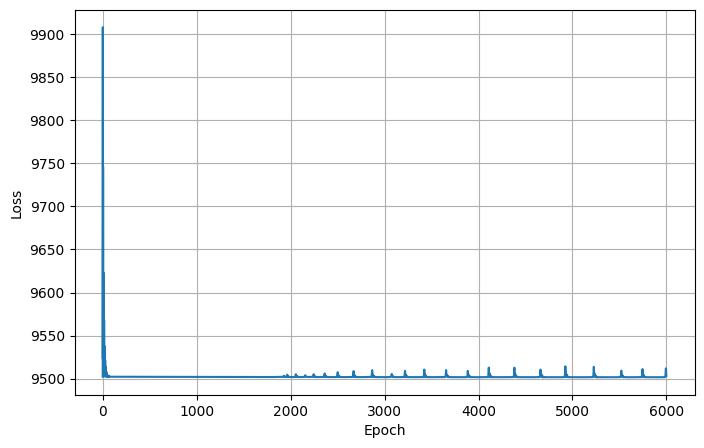

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
X_test_tf = tf.constant(X_test, dtype=tf.float32)

tau_corr = model.predict(X_test_tf)
print(tau_corr[:10])

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step
[[ 18.257538]
 [-38.854378]
 [ 12.232636]
 [-34.870453]
 [-11.187239]
 [-34.833023]
 [ 23.751665]
 [ 21.070393]
 [ 29.51442 ]
 [ 20.2429  ]]


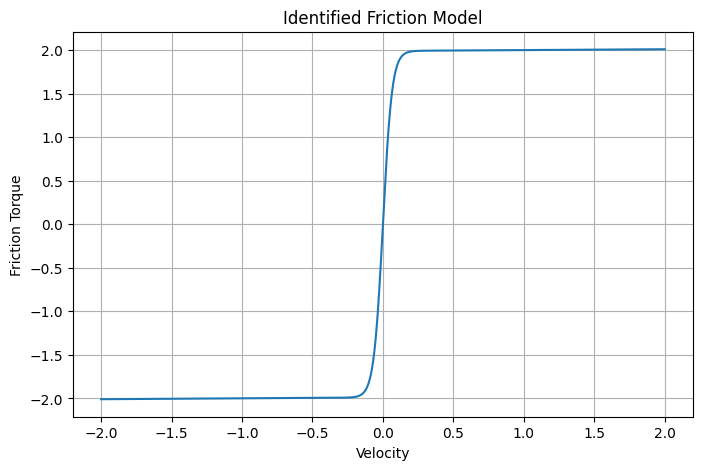

In [ ]:
v_range = np.linspace(-2, 2, 1000)

friction = (Tc.numpy() * np.tanh(v_range / Vs.numpy()) + Bv.numpy() * v_range)

plt.figure(figsize=(8,5))
plt.plot(v_range, friction)
plt.xlabel("Velocity")
plt.ylabel("Friction Torque")
plt.title("Identified Friction Model")
plt.grid()
plt.show()